In [1]:
# 08_power_curves.ipynb — load, summarize, and plot power/FDR across n and rho.
from pathlib import Path
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import os

pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", 50)

In [2]:
def find_tables_dir():
    _env = os.environ.get("LCT_TABLES")
    candidates = ([Path(_env)] if _env else []) + [Path("../results/tables"), Path("results/tables"), Path("../../results/tables")]
    for d in candidates:
        if d.exists():
            return d
    # create the default under parent repo root
    root = Path(".."); (root / "results" / "tables").mkdir(parents=True, exist_ok=True)
    return root / "results" / "tables"

TABLES = find_tables_dir()
files = sorted(TABLES.glob("power_*_p*.csv"))

print("TABLES =", TABLES.resolve())
print("Found", len(files), "power_* CSVs")
if files: print("e.g.", files[0].name)

# Load if present; keep df empty if none (so rest of cells won't crash)
df = pd.concat([pd.read_csv(f).assign(file=f.name) for f in files], ignore_index=True) if files else pd.DataFrame()
df.head()

TABLES = /workspaces/fdr-correlations/paper_results/tables
Found 72 power_* CSVs
e.g. power_exp_cl_p250_n120_rho0.5_b20_R300.csv


,model,x_model,p,n,rho,block,seed,R_bh_0.05,V_bh_0.05,S_bh_0.05,R_by_0.05,V_by_0.05,S_by_0.05,fdr_bh_0.05,power_bh_0.05,fdr_by_0.05,power_by_0.05,R_bh_0.1,V_bh_0.1,S_bh_0.1,R_by_0.1,V_by_0.1,S_by_0.1,fdr_bh_0.1,power_bh_0.1,...,R_lct_0.05,V_lct_0.05,S_lct_0.05,fdr_lct_0.05,power_lct_0.05,t_lct_0.1,R_lct_0.1,V_lct_0.1,S_lct_0.1,fdr_lct_0.1,power_lct_0.1,t_lctb_0.05_B100,R_lctb_0.05_B100,V_lctb_0.05_B100,S_lctb_0.05_B100,fdr_lctb_0.05_B100,power_lctb_0.05_B100,t_lctb_0.1_B100,R_lctb_0.1_B100,V_lctb_0.1_B100,S_lctb_0.1_B100,fdr_lctb_0.1_B100,power_lctb_0.1_B100,wall_time_s,file
0,exp_cl,exp_cl,250,120,0.5,20,0,56,10,46,9,1,8,0.178571,0.242105,0.111111,0.042105,77,15,62,17,3,14,0.194805,0.326316,...,0,0,0,0.000000,0.000000,inf,0,0,0,0.000000,0.000000,2.784154,24,3,21,0.125000,0.110526,2.495594,48,8,40,0.166667,0.210526,1.663658,power_exp_cl_p250_n120_rho0.5_b20_R300.csv
1,exp_cl,exp_cl,250,120,0.5,20,1,134,8,126,75,1,74,0.059701,0.663158,0.013333,0.389474,154,19,135,92,2,90,0.123377,0.710526,...,32,0,32,0.000000,0.168421,3.936567,38,0,38,0.000000,0.200000,2.453805,117,4,113,0.034188,0.594737,2.326385,130,8,122,0.061538,0.642105,1.372673,power_exp_cl_p250_n120_rho0.5_b20_R300.csv
2,exp_cl,exp_cl,250,120,0.5,20,2,136,13,123,50,0,50,0.095588,0.647368,0.000000,0.263158,155,20,135,74,0,74,0.129032,0.710526,...,24,0,24,0.000000,0.126316,3.975197,27,0,27,0.000000,0.142105,2.500745,113,3,110,0.026549,0.578947,2.323358,137,12,125,0.087591,0.657895,1.542361,power_exp_cl_p250_n120_rho0.5_b20_R300.csv
3,exp_cl,exp_cl,250,120,0.5,20,3,156,17,139,91,2,89,0.108974,0.731579,0.021978,0.468421,191,35,156,108,3,105,0.183246,0.821053,...,35,0,35,0.000000,0.184211,3.782982,50,0,50,0.000000,0.263158,2.465326,125,7,118,0.056000,0.621053,2.292094,156,19,137,0.121795,0.721053,1.272693,power_exp_cl_p250_n120_rho0.5_b20_R300.csv
4,exp_cl,exp_cl,250,120,0.5,20,4,199,25,174,130,2,128,0.125628,0.915789,0.015385,0.673684,226,47,179,147,4,143,0.207965,0.942105,...,87,1,86,0.011494,0.452632,3.610222,98,1,97,0.010204,0.510526,2.375712,166,11,155,0.066265,0.815789,2.201367,193,25,168,0.129534,0.884211,1.466476,power_exp_cl_p250_n120_rho0.5_b20_R300.csv


In [3]:
def melt_prefix(df, prefix):
    cols = [c for c in df.columns if isinstance(c, str) and c.startswith(prefix)]
    if not cols: 
        return pd.DataFrame()
    id_vars = [c for c in df.columns if c not in cols]
    long = df.melt(id_vars=id_vars, value_vars=cols, var_name="metric", value_name="val")
    return long

def parse_alpha(metric):
    m = re.search(r'_(0\.05|0\.10)', str(metric))
    return m.group(1) if m else None

def parse_B(metric):
    m = re.search(r'_B(\d+)', str(metric))
    return int(m.group(1)) if m else None

def label_method(metric):
    s = str(metric)
    if "_bh_"   in s: return "BH"
    if "_by_"   in s: return "BY"
    if "_lctb_" in s: return "LCT-B"
    if "_lct_"  in s: return "LCT-N"
    return "?"

def choose_lctb_rows(long_lctb, B_choice=None):
    """
    Pick which LCT-B (B) to visualize:
      - B_choice is an int: keep that B only (if present)
      - B_choice is None: choose the largest B within each (file, model, p, n, rho, alpha) group
    """
    if long_lctb.empty:
        return long_lctb
    if B_choice is not None:
        return long_lctb[long_lctb["B"] == int(B_choice)].copy()
    idx = (long_lctb
           .groupby(["file","model","p","n","rho","alpha"])["B"]
           .idxmax())
    return long_lctb.loc[idx].copy()

In [4]:
if df.empty:
    print("No power_* CSVs loaded — run scripts/run_power_curves.py first.")
else:
    # Power
    pwr_parts = []
    for pref in ["power_bh_", "power_by_", "power_lct_", "power_lctb_"]:
        L = melt_prefix(df, pref)
        if L.empty: 
            continue
        L["alpha"]  = L["metric"].apply(parse_alpha).fillna("-")
        L["B"]      = L["metric"].apply(parse_B)
        L["method"] = L["metric"].apply(label_method)
        pwr_parts.append(L.rename(columns={"val":"power"}))
    power_long = pd.concat(pwr_parts, ignore_index=True) if pwr_parts else pd.DataFrame()

    # If multiple B for LCT-B, choose one to display (largest by default)
    lctb = power_long[power_long["method"]=="LCT-B"]
    keep_lctb = choose_lctb_rows(lctb, B_choice=None)
    power_disp = pd.concat([
        power_long[power_long["method"]!="LCT-B"], 
        keep_lctb
    ], ignore_index=True)

    # FDR
    fdr_parts = []
    for pref in ["fdr_bh_", "fdr_by_", "fdr_lct_", "fdr_lctb_"]:
        L = melt_prefix(df, pref)
        if L.empty: 
            continue
        L["alpha"]  = L["metric"].apply(parse_alpha).fillna("-")
        L["B"]      = L["metric"].apply(parse_B)
        L["method"] = L["metric"].apply(label_method)
        fdr_parts.append(L.rename(columns={"val":"fdr"}))
    fdr_long = pd.concat(fdr_parts, ignore_index=True) if fdr_parts else pd.DataFrame()
    lctb_f = fdr_long[fdr_long["method"]=="LCT-B"]
    keep_lctb_f = choose_lctb_rows(lctb_f, B_choice=None)
    fdr_disp = pd.concat([
        fdr_long[fdr_long["method"]!="LCT-B"],
        keep_lctb_f
    ], ignore_index=True)

    # Aggregate
    def agg_mean_se(fr, ycol):
        if fr.empty: 
            return pd.DataFrame()
        return (fr.groupby(["file","model","p","n","rho","alpha","method"], as_index=False)[ycol]
                  .agg(mean="mean", se=lambda x: x.std(ddof=1)/np.sqrt(len(x))))
    agg_power = agg_mean_se(power_disp, "power")
    agg_fdr   = agg_mean_se(fdr_disp,   "fdr")

    display(agg_power.head())
    display(agg_fdr.head())

,file,model,p,n,rho,alpha,method,mean,se
0,power_exp_cl_p250_n120_rho0.5_b20_R300.csv,exp_cl,250,120,0.5,-,BH,0.744860,0.009228
1,power_exp_cl_p250_n120_rho0.5_b20_R300.csv,exp_cl,250,120,0.5,-,BY,0.506421,0.012107
2,power_exp_cl_p250_n120_rho0.5_b20_R300.csv,exp_cl,250,120,0.5,-,LCT-B,0.210526,NaN
3,power_exp_cl_p250_n120_rho0.5_b20_R300.csv,exp_cl,250,120,0.5,-,LCT-N,0.324404,0.012317
4,power_exp_cl_p250_n120_rho0.5_b20_R300.csv,exp_cl,250,120,0.5,0.05,BH,0.674877,0.010490


,file,model,p,n,rho,alpha,method,mean,se
0,power_exp_cl_p250_n120_rho0.5_b20_R300.csv,exp_cl,250,120,0.5,-,BH,0.155558,0.001789
1,power_exp_cl_p250_n120_rho0.5_b20_R300.csv,exp_cl,250,120,0.5,-,BY,0.026478,0.001419
2,power_exp_cl_p250_n120_rho0.5_b20_R300.csv,exp_cl,250,120,0.5,-,LCT-B,0.166667,NaN
3,power_exp_cl_p250_n120_rho0.5_b20_R300.csv,exp_cl,250,120,0.5,-,LCT-N,0.001729,0.000873
4,power_exp_cl_p250_n120_rho0.5_b20_R300.csv,exp_cl,250,120,0.5,0.05,BH,0.089894,0.001570


In [5]:
def nice_title(file):
    m = re.search(r'power_(\w+)_p(\d+)_n(\d+)_rho([0-9.]+)_b(\d+)_R(\d+)\.csv', file)
    # files contain one (n,rho); we’ll build titles ad-hoc below
    return file

def plot_power_vs_rho(model, p, n, alpha="0.05"):
    sub = agg_power[(agg_power["model"]==model)&(agg_power["p"]==p)&(agg_power["n"]==n)&(agg_power["alpha"]==alpha)]
    if sub.empty:
        print(f"No data for {model}, p={p}, n={n}, alpha={alpha}"); 
        return
    plt.figure(figsize=(6.5,3.0))
    for m in ["BH","BY","LCT-N","LCT-B"]:
        s = sub[sub["method"]==m].sort_values("rho")
        if s.empty: continue
        plt.errorbar(s["rho"], s["mean"], yerr=s["se"], marker="o", label=m)
    plt.ylim(0,1); plt.xlabel("rho"); plt.ylabel("power")
    plt.title(f"{model} | p={p} | n={n} — Power vs rho @ α={alpha}")
    plt.legend(); plt.tight_layout(); plt.show()

def plot_power_vs_n(model, p, rho, alpha="0.05"):
    sub = agg_power[(agg_power["model"]==model)&(agg_power["p"]==p)&(agg_power["rho"]==rho)&(agg_power["alpha"]==alpha)]
    if sub.empty:
        print(f"No data for {model}, p={p}, rho={rho}, alpha={alpha}"); 
        return
    plt.figure(figsize=(6.5,3.0))
    for m in ["BH","BY","LCT-N","LCT-B"]:
        s = sub[sub["method"]==m].sort_values("n")
        if s.empty: continue
        plt.errorbar(s["n"], s["mean"], yerr=s["se"], marker="o", label=m)
    plt.ylim(0,1); plt.xlabel("n"); plt.ylabel("power")
    plt.title(f"{model} | p={p} | rho={rho:.2f} — Power vs n @ α={alpha}")
    plt.legend(); plt.tight_layout(); plt.show()

def plot_fdr_vs_rho(model, p, n, alpha="0.05"):
    sub = agg_fdr[(agg_fdr["model"]==model)&(agg_fdr["p"]==p)&(agg_fdr["n"]==n)&(agg_fdr["alpha"]==alpha)]
    if sub.empty: 
        print(f"No FDR data for {model}, p={p}, n={n}, alpha={alpha}")
        return
    plt.figure(figsize=(6.5,3.0))
    for m in ["BH","BY","LCT-N","LCT-B"]:
        s = sub[sub["method"]==m].sort_values("rho")
        if s.empty: continue
        plt.errorbar(s["rho"], s["mean"], yerr=s["se"], marker="o", label=m)
    plt.xlabel("rho"); plt.ylabel("FDR"); plt.ylim(0,1)
    plt.title(f"{model} | p={p} | n={n} — FDR vs rho @ α={alpha}")
    plt.legend(); plt.tight_layout(); plt.show()

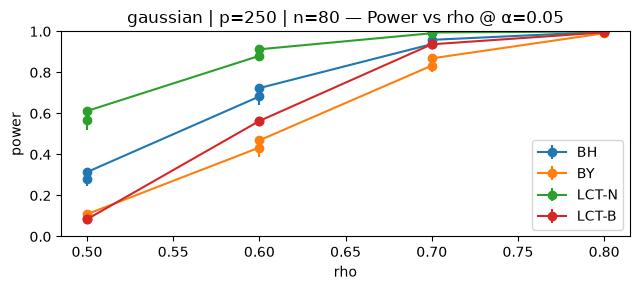

No data for gaussian, p=250, rho=0.3, alpha=0.05
No data for t, p=250, n=80, alpha=0.05
No data for t, p=250, rho=0.3, alpha=0.05
No data for laplace, p=250, n=80, alpha=0.05
No data for laplace, p=250, rho=0.3, alpha=0.05
No data for exp, p=250, n=80, alpha=0.05
No data for exp, p=250, rho=0.3, alpha=0.05


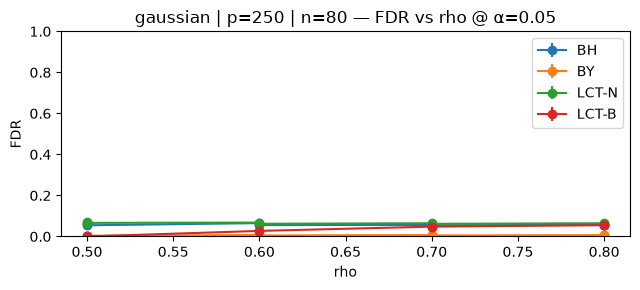

No FDR data for t, p=250, n=80, alpha=0.05
No FDR data for laplace, p=250, n=80, alpha=0.05
No FDR data for exp, p=250, n=80, alpha=0.05


In [6]:
# Examples — change these as needed
for model in ["gaussian","t","laplace","exp"]:
    plot_power_vs_rho(model, p=250, n=80, alpha="0.05")
    plot_power_vs_n(model,   p=250, rho=0.30, alpha="0.05")

# Optional: FDR sanity plots
for model in ["gaussian","t","laplace","exp"]:
    plot_fdr_vs_rho(model, p=250, n=80, alpha="0.05")

In [7]:
OUT = (TABLES.parent / "summary"); OUT.mkdir(parents=True, exist_ok=True)

if not agg_power.empty:
    out_p = OUT / "power_summary.csv"
    agg_power.to_csv(out_p, index=False)
    print("Wrote", out_p)

if not agg_fdr.empty:
    out_f = OUT / "fdr_summary.csv"
    agg_fdr.to_csv(out_f, index=False)
    print("Wrote", out_f)

Wrote /workspaces/fdr-correlations/paper_results/summary/power_summary.csv
Wrote /workspaces/fdr-correlations/paper_results/summary/fdr_summary.csv
